In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

In [2]:
df = pd.read_parquet("../data/processed/merged_dataset_with_uniprot_esm2.parquet")

In [3]:
df.shape

(2058302, 12)

In [4]:
df.head()

,source,id,chains,organism,taxonomy_id,sequence,disorder_mask,coverage,bfactor,keywords,go,embedding
0,disprot,A0A024B7W1,None,Zika virus (isolate ZIKV/Human/French Polynesi...,2043570,MKNPKKKSGGFRIVNMLKRGVARVSPFGGLKRLPAGLLLGHGPIRM...,0000000000000000000000000000000000000000000000...,NaN,None,"[3D-structure, 4Fe-4S, Acetylation, Activation...","[{'id': 'GO:0005813', 'term': 'C:centrosome', ...","[0.023399611935019493, -0.005024984013289213, ..."
1,disprot,A0A078IB52,None,Brassica napus,3708,MQYYETREKEYYDVAQGQSRQSYGQNHQGYGQSQSRPVYGNSPTLN...,1111111111111111111111111111111111111111111111...,NaN,None,None,None,"[-0.24985890090465546, 0.047941118478775024, 0..."
2,disprot,A0A096W0X9,None,Influenza A virus,1402874,MSLLTEVETPTRSEWECRCSDSSDPLVIAANIIGILHLILWITDRL...,0000000000000000000000000000000000000000000111...,NaN,None,None,None,"[0.02373121678829193, -0.054947756230831146, 0..."
3,disprot,A0A097F4I8,None,Lassa mammarenavirus,11620,MGNKQVKAPEARNSPRASLIPDATHLGPQFCKSCWFENKGLVECNN...,1111111111111111111111110000000000000000000000...,NaN,None,None,None,"[-0.07375399768352509, -0.21048112213611603, -..."
4,disprot,A0A0B4JDC9,None,Drosophila melanogaster,7227,MHLCEFPSANVEEENRRPEKAAAAASKKQKHKQQKSRPRGSHSMPY...,0000000000000000000000000000000000000000000000...,NaN,None,None,None,"[0.045096151530742645, -0.02335791289806366, 0..."


In [5]:
df["go"].iloc[0]

array([{'id': 'GO:0005813', 'term': 'C:centrosome', 'evidence': 'IDA:UniProt'},
       {'id': 'GO:0005576', 'term': 'C:extracellular region', 'evidence': 'IEA:UniProtKB-SubCell'},
       {'id': 'GO:0044167', 'term': 'C:host cell endoplasmic reticulum membrane', 'evidence': 'IEA:UniProtKB-SubCell'},
       {'id': 'GO:0044196', 'term': 'C:host cell nucleolus', 'evidence': 'IEA:UniProtKB-SubCell'},
       {'id': 'GO:0044220', 'term': 'C:host cell perinuclear region of cytoplasm', 'evidence': 'IEA:UniProtKB-SubCell'},
       {'id': 'GO:0019028', 'term': 'C:viral capsid', 'evidence': 'IEA:UniProtKB-KW'},
       {'id': 'GO:0019031', 'term': 'C:viral envelope', 'evidence': 'IEA:UniProtKB-KW'},
       {'id': 'GO:0055036', 'term': 'C:virion membrane', 'evidence': 'IEA:UniProtKB-SubCell'},
       {'id': 'GO:0051539', 'term': 'F:4 iron, 4 sulfur cluster binding', 'evidence': 'IEA:UniProtKB-KW'},
       {'id': 'GO:0005524', 'term': 'F:ATP binding', 'evidence': 'IEA:UniProtKB-KW'},
       {'id': 'G

In [6]:
df["go_ids"] = df["go"].apply(
    lambda arr: [d["id"] for d in arr] if isinstance(arr, (list, np.ndarray)) else []
)

In [7]:
df["keywords"] = df["keywords"].apply(
    lambda lst: [s.lower() for s in lst] if isinstance(lst, (list, np.ndarray)) else lst
)

In [8]:
df.head()

,source,id,chains,organism,taxonomy_id,sequence,disorder_mask,coverage,bfactor,keywords,go,embedding,go_ids
0,disprot,A0A024B7W1,None,Zika virus (isolate ZIKV/Human/French Polynesi...,2043570,MKNPKKKSGGFRIVNMLKRGVARVSPFGGLKRLPAGLLLGHGPIRM...,0000000000000000000000000000000000000000000000...,NaN,None,"[3d-structure, 4fe-4s, acetylation, activation...","[{'id': 'GO:0005813', 'term': 'C:centrosome', ...","[0.023399611935019493, -0.005024984013289213, ...","[GO:0005813, GO:0005576, GO:0044167, GO:004419..."
1,disprot,A0A078IB52,None,Brassica napus,3708,MQYYETREKEYYDVAQGQSRQSYGQNHQGYGQSQSRPVYGNSPTLN...,1111111111111111111111111111111111111111111111...,NaN,None,None,None,"[-0.24985890090465546, 0.047941118478775024, 0...",[]
2,disprot,A0A096W0X9,None,Influenza A virus,1402874,MSLLTEVETPTRSEWECRCSDSSDPLVIAANIIGILHLILWITDRL...,0000000000000000000000000000000000000000000111...,NaN,None,None,None,"[0.02373121678829193, -0.054947756230831146, 0...",[]
3,disprot,A0A097F4I8,None,Lassa mammarenavirus,11620,MGNKQVKAPEARNSPRASLIPDATHLGPQFCKSCWFENKGLVECNN...,1111111111111111111111110000000000000000000000...,NaN,None,None,None,"[-0.07375399768352509, -0.21048112213611603, -...",[]
4,disprot,A0A0B4JDC9,None,Drosophila melanogaster,7227,MHLCEFPSANVEEENRRPEKAAAAASKKQKHKQQKSRPRGSHSMPY...,0000000000000000000000000000000000000000000000...,NaN,None,None,None,"[0.045096151530742645, -0.02335791289806366, 0...",[]


In [9]:
structural_go = {
    "GO:0005198",
    "GO:0005200",
    "GO:0005201",
    "GO:0005199",
    "GO:0005212",
    "GO:0017056",
    "GO:0030527",
    "GO:0008307",
    "GO:0042302",
    "GO:0039660",
}

structural_kw = {
    "collagen",
    "keratin",
    "cytoskeleton",
    "extracellular matrix",
    "cell wall",
    "peptidoglycan",
}

In [10]:
def hits(lst, target):
    return (
        bool(set(lst) & target)
        if hasattr(lst, "__iter__") and not isinstance(lst, str)
        else False
    )


mask = df["go_ids"].apply(lambda l: hits(l, structural_go)) | df["keywords"].apply(
    lambda l: hits(l, structural_kw)
)

structural_df = df[mask]

In [11]:
structural_df.shape

(52282, 13)

In [12]:
non_structural_mask = ~mask

non_structural_with_go = df[non_structural_mask & (df["go_ids"].apply(len) > 0)]

sampled_df = non_structural_with_go.sample(
    n=min(structural_df.shape[0], len(non_structural_with_go)), random_state=42
)

print(len(sampled_df))

52282


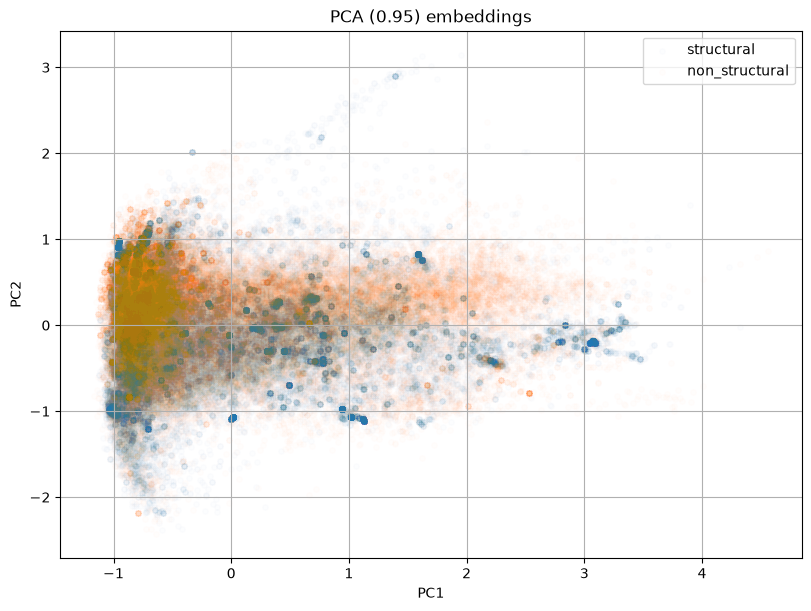

In [13]:
combined = pd.concat(
    [
        structural_df.assign(dataset="structural"),
        sampled_df.assign(dataset="non_structural"),
    ],
    ignore_index=True,
)


embeddings = np.vstack(combined["embedding"].values)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

for label, color in [("structural", "tab:blue"), ("non_structural", "tab:orange")]:
    mask = combined["dataset"] == label
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=label,
        alpha=0.01,
        s=15,
        c=color,
    )

ax.set_title("PCA (0.95) embeddings")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
ax.grid(True)

plt.show()


In [15]:
X = np.vstack(combined["embedding"].values)
y = (combined["dataset"] == "structural").astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = CatBoostClassifier(
    eval_metric="AUC",
    random_seed=42,
)
model.fit(X_train, y_train, eval_set=(X_test, y_test))

y_proba = model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_proba))

Learning rate set to 0.094571
0:	test: 0.7816168	best: 0.7816168 (0)	total: 284ms	remaining: 4m 43s
1:	test: 0.8213858	best: 0.8213858 (1)	total: 372ms	remaining: 3m 5s
2:	test: 0.8373454	best: 0.8373454 (2)	total: 453ms	remaining: 2m 30s
3:	test: 0.8486006	best: 0.8486006 (3)	total: 527ms	remaining: 2m 11s
4:	test: 0.8531073	best: 0.8531073 (4)	total: 611ms	remaining: 2m 1s
5:	test: 0.8584139	best: 0.8584139 (5)	total: 685ms	remaining: 1m 53s
6:	test: 0.8625211	best: 0.8625211 (6)	total: 759ms	remaining: 1m 47s
7:	test: 0.8649946	best: 0.8649946 (7)	total: 828ms	remaining: 1m 42s
8:	test: 0.8673795	best: 0.8673795 (8)	total: 900ms	remaining: 1m 39s
9:	test: 0.8717656	best: 0.8717656 (9)	total: 969ms	remaining: 1m 35s
10:	test: 0.8743299	best: 0.8743299 (10)	total: 1.04s	remaining: 1m 33s
11:	test: 0.8770757	best: 0.8770757 (11)	total: 1.11s	remaining: 1m 31s
12:	test: 0.8786188	best: 0.8786188 (12)	total: 1.18s	remaining: 1m 29s
13:	test: 0.8804004	best: 0.8804004 (13)	total: 1.25s	re